## Customer Segmentation

Group customers into meaningful segments using only their behavior (no labels).

Features:
- total spending
- number of purchases
- average bill

In [96]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

X = df[["total_bill", "size", "tip"]]
X.describe()

,total_bill,size,tip
count,244.000000,244.000000,244.000000
mean,19.785943,2.569672,2.998279
std,8.902412,0.951100,1.383638
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.000000,2.900000
75%,24.127500,3.000000,3.562500
max,50.810000,6.000000,10.000000


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

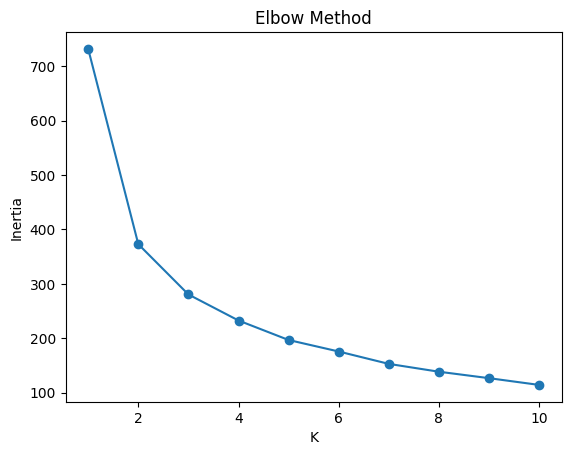

In [98]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
plt.figure()
plt.plot(K_range, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
    

k = 3 is optimal

In [99]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [100]:
X["cluster"] = labels
X.head()

C:\Users\Shail Patel\AppData\Local\Temp\ipykernel_30728\1951423719.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["cluster"] = labels


,total_bill,size,tip,cluster
0,16.99,2,1.01,2
1,10.34,3,1.66,2
2,21.01,3,3.50,0
3,23.68,2,3.31,0
4,24.59,4,3.61,1


In [101]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = labels

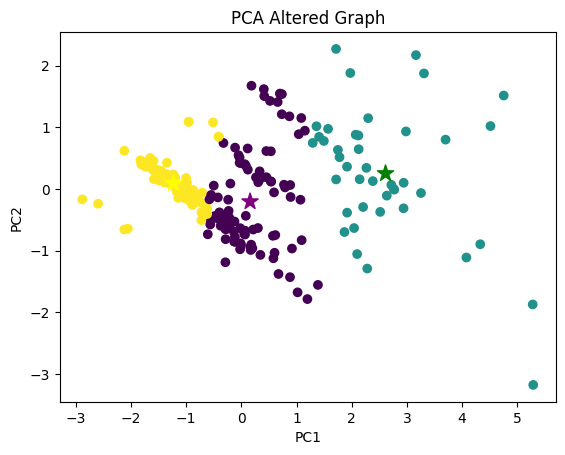

In [102]:
plt.figure()
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c = pca_df["cluster"]
)
plt.title("PCA Altered Graph")
plt.xlabel("PC1")
plt.ylabel("PC2")

centroids_pca = pca.transform(centroids)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="*",
    s = 150,
    c=["purple", "green", "yellow"]
)
plt.show()

In [103]:
X.groupby("cluster").mean()

,total_bill,size,tip
cluster,,,
0,21.167900,2.490000,3.260600
1,33.494524,4.119048,4.873095
2,12.786373,2.009804,1.969118


## Customer Sex Prediction

Problem statement

- You are given customer transaction data.

Goal:

- Build a model that predicts customer sex using spending behavior.

In [104]:
import seaborn as sns

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [132]:
X = df[["total_bill", "tip"]]
y = df["sex"]

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Female       0.00      0.00      0.00        19
        Male       0.61      1.00      0.76        30

    accuracy                           0.61        49
   macro avg       0.31      0.50      0.38        49
weighted avg       0.37      0.61      0.46        49



c:\Users\Shail Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shail Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shail Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

### Same project using KNN

In [179]:
df = sns.load_dataset("tips")
df["smoker"] = df["smoker"].map({"Yes":1, "No":0})
df["time"] = df["time"].map({"Dinner":1, "Lunch":0})

X = df[["total_bill", "tip", "smoker", "size", "time"]]
y = df["sex"]

In [180]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [181]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "knn__n_neighbors": randint(3, 30),
    "knn__weights": ["uniform", "distance"]
}

random_search = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_dist,
    n_iter=20,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'knn__n_neighbors': 5, 'knn__weights': 'distance'}
0.5724851549157876


In [183]:
from sklearn.metrics import classification_report

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      Female       0.40      0.32      0.35        19
        Male       0.62      0.70      0.66        30

    accuracy                           0.55        49
   macro avg       0.51      0.51      0.50        49
weighted avg       0.53      0.55      0.54        49

